# WESAD + SSL TimePatch Transformer

Incluye:
- cargar WESAD
- usar solo BVP, EDA, TEMP wrist
- convertir el problema a stress vs no-stress
- usar un TimePatch Transformer
- hacer self-supervised learning
- generar datos sintéticos parecidos a WESAD para aumentación
- evaluar con LOSO sobre sujetos reales

La idea central es comparar tres escenarios:
- solo supervisado
- SSL + supervisado
- SSL + datos sintéticos + supervisado

In [35]:

#!pip -q install numpy scipy scikit-learn matplotlib tqdm pandas

In [36]:

import os
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import LeaveOneGroupOut

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


## Configurando la ruta del dataset

OJO: estructura esperada:

```text
WESAD/
  S2/S2.pkl
  S3/S3.pkl
  ...
```

In [37]:
#from google.colab import drive
#drive.mount('/content/drive/')

In [38]:

WESAD_ROOT = "WESAD/WESAD/"   # OJO actualicen al dataset
#la frecuencia objetivo:
TARGET_FS = 4
#la longitud de ventana:
WINDOW_SECONDS = 60
#el salto entre ventanas:
WINDOW_STRIDE_SECONDS = 30

USE_LABELS = {1, 2, 3}   # baseline, stress, amusement
STRESS_LABEL = 2
NOSTRESS_LABELS = {1, 3} #convirtiendo a binario

## cargando WESAD

In [39]:

#Cada señal de WESAD puede venir con distinta frecuencia.
#Esta función la remuestrea a una frecuencia común:
#todo se lleva a 4 Hz
#Esto sirve para que las tres señales tengan la misma longitud temporal y puedan entrar juntas al modelo.
def resample_1d(x, orig_fs, target_fs):
    x = np.asarray(x).squeeze()
    if orig_fs == target_fs:
        return x.astype(np.float32)
    duration = len(x) / float(orig_fs)
    target_len = max(2, int(round(duration * target_fs)))
    return signal.resample(x, target_len).astype(np.float32)

#Esta función normaliza cada señal de forma robusta usando:
#mediana
#rango intercuartílico

#Se usa esto en lugar de una normalización simple con media/desviación porque las señales fisiológicas suelen tener:
#picos
#ruido
#valores atípicos

#Así el modelo aprende patrones más estables entre sujetos.
def robust_norm(x):
    x = np.asarray(x, dtype=np.float32)
    x = np.nan_to_num(x, nan=np.nanmedian(x) if np.isnan(x).any() else 0.0)
    med = np.median(x)
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    scale = iqr if iqr > 1e-6 else (np.std(x) + 1e-6)
    return ((x - med) / scale).astype(np.float32)

#Esta función abre el .pkl de cada sujeto y extrae solo:

#BVP
#EDA
#TEMP
#label

#Luego:

#remuestrea cada señal a 4 Hz
#alinea las señales y etiquetas
#normaliza
#deja listo un arreglo temporal con 3 canales
def load_wesad_subject(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    wrist = data["signal"]["wrist"]
    labels = np.asarray(data["label"]).astype(int).squeeze()

    bvp = np.asarray(wrist["BVP"]).squeeze()
    eda = np.asarray(wrist["EDA"]).squeeze()
    temp = np.asarray(wrist["TEMP"]).squeeze()

    fs_bvp = 64
    fs_eda = 4
    fs_temp = 4
    fs_label = 700

    bvp = resample_1d(bvp, fs_bvp, TARGET_FS)
    eda = resample_1d(eda, fs_eda, TARGET_FS)
    temp = resample_1d(temp, fs_temp, TARGET_FS)
    labels = resample_1d(labels, fs_label, TARGET_FS).round().astype(int)

    L = min(len(bvp), len(eda), len(temp), len(labels))
    X = np.stack([
        robust_norm(bvp[:L]),
        robust_norm(eda[:L]),
        robust_norm(temp[:L]),
    ], axis=1)

    labels = labels[:L]
    keep = np.isin(labels, list(USE_LABELS))
    X = X[keep]
    labels = labels[keep]
    y = np.where(labels == STRESS_LABEL, 1, 0).astype(np.int64)
    return X, y

#Después, divide la señal continua en ventanas:

#cada ventana dura 60 s
#con stride de 30 s

#Entonces cada ventana tiene información temporal suficiente para captar respuesta fisiológica al estrés, y además se generan muchas muestras por sujeto.

#Cada ventana queda con forma aproximada:

#tiempo x canales
#o sea: T x 3
def segment_windows(X, y, window_seconds=60, stride_seconds=30, fs=4):
    win = int(window_seconds * fs)
    stride = int(stride_seconds * fs)
    Xw, yw = [], []

    for start in range(0, len(X) - win + 1, stride):
        end = start + win
        xw = X[start:end]
        yw_raw = y[start:end]
        frac = yw_raw.mean()
        if frac in [0.0, 1.0] or frac <= 0.2 or frac >= 0.8:
            Xw.append(xw.astype(np.float32))
            yw.append(int(frac >= 0.5))

    if len(Xw) == 0:
        return np.zeros((0, win, X.shape[1]), dtype=np.float32), np.zeros((0,), dtype=np.int64)

    return np.stack(Xw), np.asarray(yw, dtype=np.int64)

#Se juntan todas las ventanas de todos los sujetos en tres variables:

#X: ventanas
#y: etiquetas binarias
#groups: identificador del sujeto

#groups es clave porque se usa para la evaluación Leave-One-Subject-Out.

def load_all_wesad(root):
    X_all, y_all, groups_all = [], [], []
    subject_dirs = sorted([d for d in os.listdir(root) if d.startswith("S")])

    for subj in subject_dirs:
        pkl_path = os.path.join(root, subj, f"{subj}.pkl")
        if not os.path.exists(pkl_path):
            print("Skipping:", pkl_path)
            continue
        X, y = load_wesad_subject(pkl_path)
        Xw, yw = segment_windows(X, y, WINDOW_SECONDS, WINDOW_STRIDE_SECONDS, TARGET_FS)
        if len(Xw) == 0:
            continue
        sid = int(subj[1:])
        X_all.append(Xw)
        y_all.append(yw)
        groups_all.append(np.full(len(yw), sid))
        print(subj, Xw.shape, "stress ratio=", float(yw.mean()))

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)
    groups_all = np.concatenate(groups_all, axis=0)
    return X_all, y_all, groups_all

X, y, groups = load_all_wesad(WESAD_ROOT)
print("X:", X.shape, "y:", y.shape, "groups:", groups.shape)
print("Subjects:", np.unique(groups))
print("Stress ratio:", float(y.mean()))

S10 (73, 240, 3) stress ratio= 0.3013698630136986
S11 (71, 240, 3) stress ratio= 0.30985915492957744
S13 (72, 240, 3) stress ratio= 0.2916666666666667
S14 (71, 240, 3) stress ratio= 0.30985915492957744
S15 (72, 240, 3) stress ratio= 0.2916666666666667
S16 (71, 240, 3) stress ratio= 0.30985915492957744
S17 (73, 240, 3) stress ratio= 0.3013698630136986
S2 (67, 240, 3) stress ratio= 0.29850746268656714
S3 (68, 240, 3) stress ratio= 0.29411764705882354
S4 (70, 240, 3) stress ratio= 0.2857142857142857
S5 (70, 240, 3) stress ratio= 0.2714285714285714
S6 (70, 240, 3) stress ratio= 0.3
S7 (71, 240, 3) stress ratio= 0.28169014084507044
S8 (71, 240, 3) stress ratio= 0.29577464788732394
S9 (70, 240, 3) stress ratio= 0.3
X: (1060, 240, 3) y: (1060,) groups: (1060,)
Subjects: [ 2  3  4  5  6  7  8  9 10 11 13 14 15 16 17]
Stress ratio: 0.2962264150943396


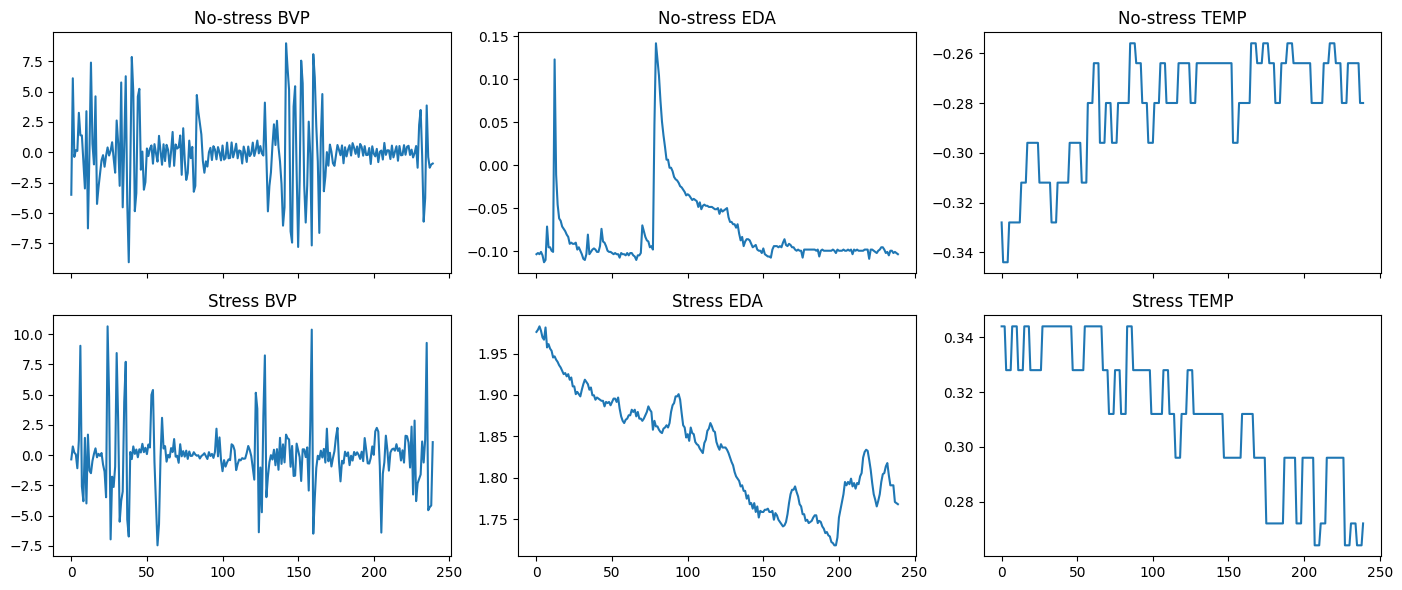

In [40]:
#Se escoge una ventana de:

#no-stress
#stress

#y se dibujan las tres señales:

#BVP
#EDA
#TEMP

#Esto no entrena nada.
#Solo sirve para comprobar visualmente que:

#la carga fue correcta
#las señales tienen forma razonable
#las dos clases muestran comportamientos distintos
# visualización rápida
names = ["BVP", "EDA", "TEMP"]
i0 = np.where(y == 0)[0][0]
i1 = np.where(y == 1)[0][0]

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for c, name in enumerate(names):
    axes[0, c].plot(X[i0, :, c])
    axes[0, c].set_title(f"No-stress {name}")
    axes[1, c].plot(X[i1, :, c])
    axes[1, c].set_title(f"Stress {name}")
plt.tight_layout()
plt.show()

## Generación de datos sintéticos tipo WESAD

Estas muestras sintéticas se generan únicamente a partir de estadísticas derivadas de WESAD.

Su propósito es complementar los datos, no sustituir la evaluación real.

In [41]:
#Para cada clase:

#no-stress
#stress

#se calculan:

#media por canal
#covarianza entre canales
#perfil espectral medio usando FFT

#Esto permite capturar dos cosas:

#el comportamiento promedio temporal
#el contenido en frecuencia de cada señal

#Con eso se define una especie de “firma” estadística de cada clase.

def estimate_class_stats(X, y):
    stats = {}
    for cls in [0, 1]:
        Xc = X[y == cls]
        flat = Xc.reshape(-1, X.shape[-1])
        mu = flat.mean(axis=0)
        cov = np.cov(flat.T) + 1e-4 * np.eye(X.shape[-1])

        amps = []
        for sample in Xc[:min(len(Xc), 300)]:
            sample_amp = []
            for ch in range(sample.shape[1]):
                sample_amp.append(np.abs(np.fft.rfft(sample[:, ch])))
            amps.append(np.stack(sample_amp, axis=0))
        amp = np.stack(amps, axis=0).mean(axis=0)
        stats[cls] = {"mu": mu, "cov": cov, "amp": amp}
    return stats

CLASS_STATS = estimate_class_stats(X, y)
CLASS_STATS.keys()

dict_keys([0, 1])

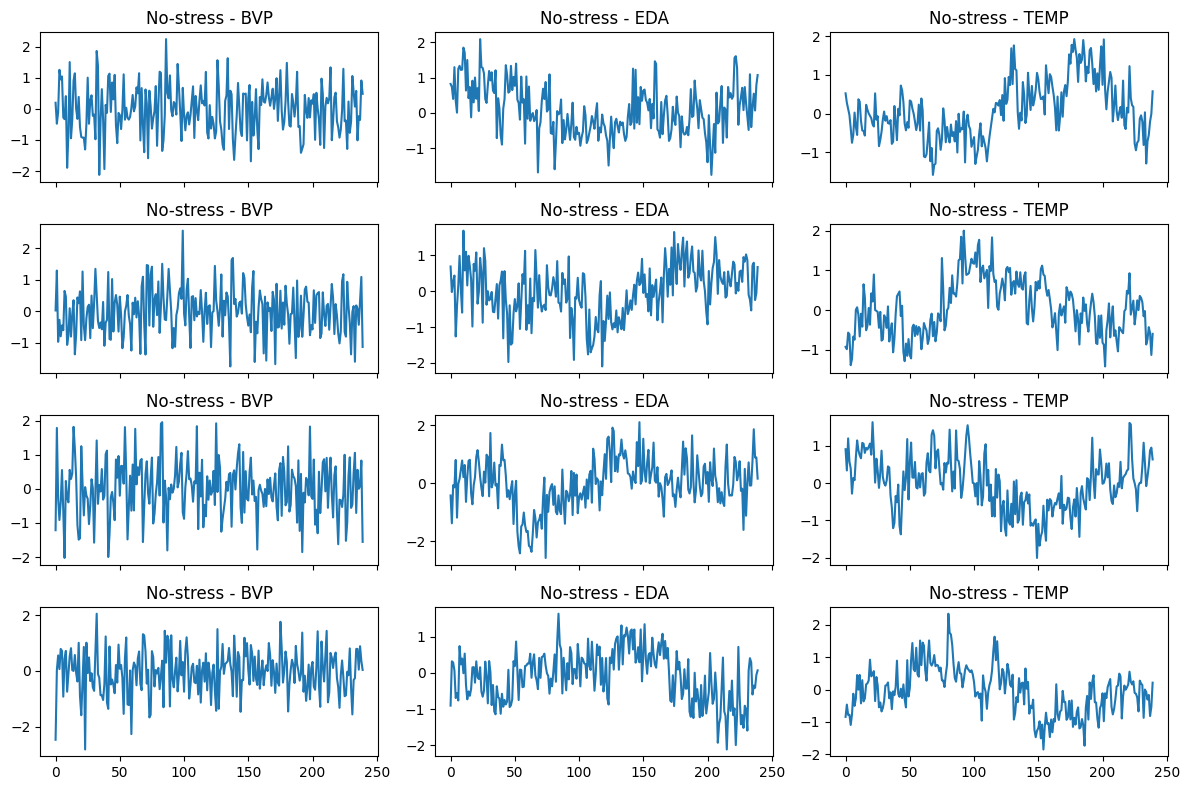

In [42]:
#Genera una curva suave aleatoria.
#Se usa para añadir variaciones lentas, parecidas a las que aparecen en fisiología real.

#Por ejemplo:

#derivas lentas en temperatura
#cambios suaves en EDA

def smooth_curve(length, scale=1.0, knots=8):
    xp = np.linspace(0, length - 1, knots)
    yp = np.random.normal(0, scale, knots)
    curve = np.interp(np.arange(length), xp, yp)
    wl = max(5, (length // 15) | 1)
    return signal.savgol_filter(curve, wl, 2).astype(np.float32)


#Esta función crea una ventana sintética para una clase concreta.

#Hace varias cosas:

#genera una base aleatoria usando la media y covarianza de esa clase
#impone una forma espectral parecida a la señal real
#añade curvas suaves para simular variaciones fisiológicas lentas
#ajusta el resultado para que se parezca a ventanas reales de WESAD

#El resultado es una ventana nueva de:

#BVP
#EDA
#TEMP

#que no es una copia exacta, pero sí mantiene propiedades parecidas a la clase real.

def generate_synthetic_window(label, length, stats):
    base = np.random.multivariate_normal(stats[label]["mu"], stats[label]["cov"], size=length).astype(np.float32)
    out = np.zeros_like(base)

    # spectral shaping
    for c in range(base.shape[1]):
        phase = np.random.uniform(0, 2*np.pi, size=stats[label]["amp"].shape[-1])
        spec = stats[label]["amp"][c] * np.exp(1j * phase)
        seq = np.fft.irfft(spec, n=length).real.astype(np.float32)
        seq = (seq - seq.mean()) / (seq.std() + 1e-6)
        out[:, c] = 0.5 * base[:, c] + 0.5 * seq

    t = np.linspace(0, 1, length).astype(np.float32)

    # BVP oscillation
    freq = 1.1 + 0.35 * label + np.random.uniform(-0.12, 0.12)
    out[:, 0] += 0.35 * np.sin(2 * np.pi * freq * np.arange(length) / TARGET_FS).astype(np.float32)

    # EDA peaks
    n_peaks = np.random.randint(4, 9) if label == 1 else np.random.randint(1, 4)
    idx = np.arange(length)
    for _ in range(n_peaks):
        center = np.random.randint(0, length)
        width = np.random.uniform(2, 10)
        amp = np.random.uniform(0.3, 1.0) * (1.2 if label == 1 else 0.8)
        out[:, 1] += amp * np.exp(-0.5 * ((idx - center) / width) ** 2)

    # TEMP drift
    out[:, 2] += ((-0.35 if label == 1 else 0.08) * t + smooth_curve(length, scale=0.05)).astype(np.float32)

    # subject-style drift
    for c in range(out.shape[1]):
        out[:, c] += 0.2 * smooth_curve(length, scale=0.12 + 0.03 * c)

    # normalize
    for c in range(out.shape[1]):
        med = np.median(out[:, c])
        iqr = np.percentile(out[:, c], 75) - np.percentile(out[:, c], 25)
        iqr = iqr if iqr > 1e-6 else out[:, c].std() + 1e-6
        out[:, c] = (out[:, c] - med) / iqr

    return out.astype(np.float32)

#Con la función anterior se pueden generar muchas ventanas sintéticas y crear un dataset artificial para:

#balancear clases
#aumentar el tamaño del set de entrenamiento
#probar la hipótesis de augmentación

#Importante: estos datos sintéticos solo se usan para entrenar, no para evaluar.

def generate_synthetic_dataset(n_samples, class_balance=0.5):
    ys = (np.random.rand(n_samples) < class_balance).astype(np.int64)
    Xs = np.stack([generate_synthetic_window(int(lbl), X.shape[1], CLASS_STATS) for lbl in ys], axis=0)
    return Xs, ys

Xs_demo, ys_demo = generate_synthetic_dataset(4, class_balance=float(y.mean()))
fig, axes = plt.subplots(4, 3, figsize=(12, 8), sharex=True)
for i in range(4):
    for c, name in enumerate(names):
        axes[i, c].plot(Xs_demo[i, :, c])
        axes[i, c].set_title(f"{'Stress' if ys_demo[i] else 'No-stress'} - {name}")
plt.tight_layout()
plt.show()

## Datasets y aumentaciones

In [43]:

#Convierte X y y en un formato que PyTorch puede leer con DataLoader.

#Sirve tanto para:

#entrenamiento supervisado
#entrenamiento SSL
#validación
class WindowDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]


#Esta función crea una versión modificada de una ventana.
#Las modificaciones son pequeñas, por ejemplo:

#añadir un poco de ruido
#escalar amplitud
#desplazar un poco en el tiempo
#enmascarar una parte pequeña de un canal

#Esto es fundamental para SSL, porque el modelo ve dos versiones del mismo ejemplo y aprende a reconocer que siguen representando el mismo estado fisiológico.
def weak_augment(x):
    x = x.clone()
    if random.random() < 0.8:
        x = x + 0.02 * torch.randn_like(x)
    if random.random() < 0.5:
        x = x * torch.empty((1, x.shape[1])).uniform_(0.9, 1.1)
    if random.random() < 0.4:
        shift = random.randint(-5, 5)
        x = torch.roll(x, shifts=shift, dims=0)
    if random.random() < 0.3:
        c = random.randrange(x.shape[1])
        start = random.randrange(0, max(1, x.shape[0] - 10))
        width = random.randrange(5, 15)
        x[start:start+width, c] = 0
    return x

#Genera pares (x1, x2) donde:

#x1 = una versión aumentada de la ventana
#x2 = otra versión aumentada de la misma ventana

#Esto se usa para aprendizaje contrastivo.
class SSLPairDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        return weak_augment(x), weak_augment(x)

## TimePatch Transformer

In [44]:
#En vez de meter toda la secuencia de golpe, la divide en pequeños bloques temporales llamados patches.

#Por ejemplo:

#si patch_len = 8
#entonces cada 8 pasos temporales se agrupan en un patch

#Cada patch se aplana y se proyecta a un vector latente.

#¿Por qué se hace esto?

#reduce longitud efectiva de la secuencia
#facilita que el Transformer trabaje mejor
#captura patrones locales antes de modelar dependencias largas
class PatchEmbed1D(nn.Module):
    def __init__(self, in_ch=3, patch_len=8, emb_dim=128):
        super().__init__()
        self.patch_len = patch_len
        self.proj = nn.Linear(in_ch * patch_len, emb_dim)

    def forward(self, x):
        B, T, C = x.shape
        P = self.patch_len
        T2 = (T // P) * P
        x = x[:, :T2, :].reshape(B, T2 // P, P * C)
        return self.proj(x)

#Después del patching, el modelo añade:

#un CLS token
#embeddings posicionales
#un TransformerEncoder

#Luego, el vector CLS se usa como resumen global de la ventana.

#El modelo tiene dos salidas implícitas:

#embedding para SSL
#clasificación para stress/no-stress

#En otras palabras, el Transformer aprende una representación temporal multimodal de la ventana.
class TimePatchTransformer(nn.Module):
    def __init__(self, in_ch=3, patch_len=8, emb_dim=128, depth=4, heads=4, num_classes=2):
        super().__init__()
        self.patch = PatchEmbed1D(in_ch, patch_len, emb_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, emb_dim))
        self.pos_emb = nn.Parameter(torch.zeros(1, 512, emb_dim))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=heads,
            dim_feedforward=emb_dim * 4,
            dropout=0.1,
            activation="gelu",
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=depth)
        self.norm = nn.LayerNorm(emb_dim)
        self.ssl_head = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, 64)
        )
        self.cls_head = nn.Linear(emb_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_emb, std=0.02)

    def forward_features(self, x):
        x = self.patch(x)
        B, N, D = x.shape
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_emb[:, :N+1, :]
        x = self.encoder(x)
        x = self.norm(x)
        return x[:, 0]

    def forward_ssl(self, x):
        z = self.forward_features(x)
        z = self.ssl_head(z)
        return F.normalize(z, dim=-1)

    def forward(self, x):
        z = self.forward_features(x)
        return self.cls_head(z)

## SSL y aprendizaje supervisado

In [45]:
#Esta es la pérdida contrastiva.

#La idea es:

#dos vistas aumentadas del mismo ejemplo deben quedar cerca en el espacio latente
#vistas de ejemplos distintos deben quedar lejos

#Eso obliga al modelo a aprender representaciones útiles sin usar etiquetas.
def nt_xent(z1, z2, temp=0.2):
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=-1) / temp
    sim.fill_diagonal_(-1e9)
    targets = torch.arange(B, device=z.device)
    targets = torch.cat([targets + B, targets], dim=0)
    return F.cross_entropy(sim, targets)

#Aquí se hace el preentrenamiento self-supervised.
#Pasos:

#se toman ventanas sin usar la etiqueta
#se generan dos vistas aumentadas
#el modelo produce embeddings para ambas
#se calcula la pérdida contrastiva
#se actualizan los pesos

#Resultado: el modelo aprende una representación inicial buena de las señales fisiológicas

def pretrain_ssl(model, X_unlabeled, epochs=6, batch_size=64, lr=1e-3):
    ds = SSLPairDataset(X_unlabeled)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    model.train()
    for ep in range(epochs):
        losses = []
        for x1, x2 in dl:
            x1, x2 = x1.to(DEVICE), x2.to(DEVICE)
            z1 = model.forward_ssl(x1)
            z2 = model.forward_ssl(x2)
            loss = nt_xent(z1, z2)
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())
        print(f"SSL epoch {ep+1}/{epochs}: {np.mean(losses):.4f}")
    return model

def evaluate_probs(y_true, probs):
    pred = (probs >= 0.5).astype(int)
    out = {
        "accuracy": accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
    }
    try:
        out["auroc"] = roc_auc_score(y_true, probs)
    except Exception:
        out["auroc"] = np.nan
    return out

def finetune(model, X_train, y_train, X_val, y_val, epochs=8, batch_size=64, lr=2e-4):
    train_dl = DataLoader(WindowDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(WindowDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    best_state = None
    best_f1 = -1

    for ep in range(epochs):
        model.train()
        train_losses = []

        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        probs_all, ys_all = [], []
        with torch.no_grad():
            for xb, yb in val_dl:
                xb = xb.to(DEVICE)
                probs = torch.softmax(model(xb), dim=-1)[:, 1].cpu().numpy()
                probs_all.append(probs)
                ys_all.append(yb.numpy())

        probs_all = np.concatenate(probs_all)
        ys_all = np.concatenate(ys_all)
        metrics = evaluate_probs(ys_all, probs_all)
        print(f"FT epoch {ep+1}/{epochs}: loss={np.mean(train_losses):.4f}, val_f1={metrics['f1']:.4f}")

        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model

def predict_probs(model, X_test, batch_size=128):
    dl = DataLoader(WindowDataset(X_test), batch_size=batch_size, shuffle=False)
    model.eval()
    probs = []
    with torch.no_grad():
        for xb in dl:
            xb = xb.to(DEVICE)
            p = torch.softmax(model(xb), dim=-1)[:, 1].cpu().numpy()
            probs.append(p)
    return np.concatenate(probs)

## Experimentos LOSO sobre sujetos reales de WESAD

In [46]:
#Leave-One-Group-Out, donde el grupo es el sujeto.

#Eso significa:

#en cada fold, se deja un sujeto entero para test
#el entrenamiento se hace con los demás sujetos

#Esto evita “hacer trampa” mezclando ventanas del mismo sujeto en train y test.

#Dentro de cada fold se hace esto:
#a) Separar train y test
#X_train, y_train: todos los sujetos menos uno
#X_test, y_test: el sujeto dejado fuera

#b) Separar validación dentro del train
#Una pequeña parte del entrenamiento se usa como validación.

#c) Opción: añadir sintéticos
#Si use_synth=True:
#se generan ventanas sintéticas
#se añaden al conjunto de entrenamiento real

#d) Opción: hacer SSL
#Si use_ssl=True:
#primero se preentrena con las ventanas de entrenamiento
#luego se hace fine-tuning supervisado

#e) Evaluación
#Al final se calcula el rendimiento en el sujeto real no visto.
#Se reportan métricas como:
#accuracy
#F1
#balanced accuracy
#AUROC

def run_loso(X, y, groups, use_ssl=False, use_synth=False, ssl_epochs=6, ft_epochs=8, synth_ratio=0.5):
    logo = LeaveOneGroupOut()
    results = []

    for fold, (tr_idx, te_idx) in enumerate(logo.split(X, y, groups), start=1):
        held_out = int(np.unique(groups[te_idx])[0])
        X_train, y_train = X[tr_idx], y[tr_idx]
        X_test, y_test = X[te_idx], y[te_idx]

        n_val = max(8, int(0.15 * len(X_train)))
        perm = np.random.permutation(len(X_train))
        val_idx = perm[:n_val]
        tr2_idx = perm[n_val:]

        X_tr, y_tr = X_train[tr2_idx], y_train[tr2_idx]
        X_val, y_val = X_train[val_idx], y_train[val_idx]

        if use_synth:
            Xs, ys = generate_synthetic_dataset(int(len(X_tr) * synth_ratio), class_balance=float(y_tr.mean()))
            X_tr = np.concatenate([X_tr, Xs], axis=0)
            y_tr = np.concatenate([y_tr, ys], axis=0)

        model = TimePatchTransformer(in_ch=3, patch_len=8, emb_dim=128, depth=4, heads=4, num_classes=2)

        if use_ssl:
            X_unlab = X_train.copy()
            if use_synth:
                Xu, _ = generate_synthetic_dataset(int(0.5 * len(X_train)), class_balance=float(y_train.mean()))
                X_unlab = np.concatenate([X_unlab, Xu], axis=0)
            model = pretrain_ssl(model, X_unlab, epochs=ssl_epochs)

        model = finetune(model, X_tr, y_tr, X_val, y_val, epochs=ft_epochs)
        probs = predict_probs(model, X_test)
        metrics = evaluate_probs(y_test, probs)
        metrics["subject"] = held_out
        results.append(metrics)
        print("Fold", fold, "subject", held_out, metrics)

    return results

def summarize(name, results, log_file="resultados_experimentos.txt", params=None):
    print("\n" + name)
    if params:
        print(f"Hyperparameters: {params}")
    with open(log_file, "a", encoding="utf-8") as f:
        f.write(f"\n{name}\n")
        f.write("-" * len(name) + "\n")
        if params:
            f.write(f"Hyperparameters: {params}\n")
        for key in ["accuracy", "f1", "balanced_accuracy", "auroc"]:
            vals = np.array([r[key] for r in results], dtype=float)
            line = f"{key}: {np.nanmean(vals):.4f} ± {np.nanstd(vals):.4f}"
            print(line)
            f.write(line + "\n")


###Comparación de tres escenarios

Luego el notebook ejecuta tres experimentos completos:

1) Supervised only: Entrena directamente con etiquetas, sin SSL ni sintéticos Esto es baseline principal.

2) SSL + supervised: Primero hace self-supervised pretraining y luego fine-tuning supervisado. Esto sirve para comprobar si SSL ayuda.

3) SSL + synthetic + supervised:
Hace:
- pretraining SSL
- augmentación con ventanas sintéticas
- entrenamiento supervisado
Esto sirve para comprobar si además de SSL, los datos sintéticos mejoran aún más el resultado.

In [47]:
import torch
print(f"Versión de PyTorch: {torch.__version__}")
print(f"¿CUDA disponible?: {torch.cuda.is_available()}")
print(f"Capacidad Compute: {torch.cuda.get_device_capability(0)}")

Versión de PyTorch: 2.12.0.dev20260408+cu128
¿CUDA disponible?: True
Capacidad Compute: (12, 0)


In [48]:
# 1) Supervised only
params_sup = {"use_ssl": False, "use_synth": False, "ft_epochs": 8}
res_sup = run_loso(X, y, groups, **params_sup)
summarize("Supervised only", res_sup, params=params_sup)

FT epoch 1/8: loss=0.3688, val_f1=0.8235
FT epoch 2/8: loss=0.2803, val_f1=0.8000
FT epoch 3/8: loss=0.2331, val_f1=0.7952
FT epoch 4/8: loss=0.2122, val_f1=0.8101
FT epoch 5/8: loss=0.2068, val_f1=0.8354
FT epoch 6/8: loss=0.1979, val_f1=0.8571
FT epoch 7/8: loss=0.1794, val_f1=0.8235
FT epoch 8/8: loss=0.1832, val_f1=0.8571
Fold 1 subject 2 {'accuracy': 0.9701492537313433, 'f1': 0.9523809523809523, 'balanced_accuracy': 0.9787234042553192, 'auroc': 1.0, 'subject': 2}
FT epoch 1/8: loss=0.3174, val_f1=0.8409
FT epoch 2/8: loss=0.2451, val_f1=0.8506
FT epoch 3/8: loss=0.1923, val_f1=0.8471
FT epoch 4/8: loss=0.1807, val_f1=0.8889
FT epoch 5/8: loss=0.1589, val_f1=0.9157
FT epoch 6/8: loss=0.1377, val_f1=0.9524
FT epoch 7/8: loss=0.1116, val_f1=0.9398
FT epoch 8/8: loss=0.1042, val_f1=0.9302
Fold 2 subject 3 {'accuracy': 0.6911764705882353, 'f1': 0.6181818181818182, 'balanced_accuracy': 0.7375, 'auroc': 0.8239583333333332, 'subject': 3}
FT epoch 1/8: loss=0.3990, val_f1=0.8372
FT epoch 2

In [49]:
# 2) SSL + supervised
params_ssl = {"use_ssl": True, "use_synth": False, "ssl_epochs": 6, "ft_epochs": 8}
res_ssl = run_loso(X, y, groups, **params_ssl)
summarize("SSL + supervised", res_ssl, params=params_ssl)

SSL epoch 1/6: 2.6456
SSL epoch 2/6: 2.1129
SSL epoch 3/6: 1.9295
SSL epoch 4/6: 1.8503
SSL epoch 5/6: 1.7614
SSL epoch 6/6: 1.6503
FT epoch 1/8: loss=0.3451, val_f1=0.7941
FT epoch 2/8: loss=0.2289, val_f1=0.8571
FT epoch 3/8: loss=0.2046, val_f1=0.8235
FT epoch 4/8: loss=0.1759, val_f1=0.8358
FT epoch 5/8: loss=0.1644, val_f1=0.9231
FT epoch 6/8: loss=0.1253, val_f1=0.8696
FT epoch 7/8: loss=0.0845, val_f1=0.9118
FT epoch 8/8: loss=0.0629, val_f1=0.8824
Fold 1 subject 2 {'accuracy': 1.0, 'f1': 1.0, 'balanced_accuracy': 1.0, 'auroc': 1.0, 'subject': 2}
SSL epoch 1/6: 2.6068
SSL epoch 2/6: 2.1218
SSL epoch 3/6: 1.9250
SSL epoch 4/6: 1.8483
SSL epoch 5/6: 1.7297
SSL epoch 6/6: 1.6895
FT epoch 1/8: loss=0.3846, val_f1=0.8889
FT epoch 2/8: loss=0.2011, val_f1=0.8706
FT epoch 3/8: loss=0.1804, val_f1=0.9091
FT epoch 4/8: loss=0.1454, val_f1=0.9091
FT epoch 5/8: loss=0.1163, val_f1=0.9213
FT epoch 6/8: loss=0.1115, val_f1=0.9348
FT epoch 7/8: loss=0.1092, val_f1=0.9318
FT epoch 8/8: loss=0.

In [50]:
# 3) SSL + synthetic augmentation + supervised
params_ssl_synth = {"use_ssl": True, "use_synth": True, "ssl_epochs": 6, "ft_epochs": 8, "synth_ratio": 0.5}
res_ssl_synth = run_loso(X, y, groups, **params_ssl_synth)
summarize("SSL + synthetic + supervised", res_ssl_synth, params=params_ssl_synth)

SSL epoch 1/6: 2.6930
SSL epoch 2/6: 2.1942
SSL epoch 3/6: 1.9625
SSL epoch 4/6: 1.8496
SSL epoch 5/6: 1.7571
SSL epoch 6/6: 1.6085
FT epoch 1/8: loss=0.4703, val_f1=0.7895
FT epoch 2/8: loss=0.3071, val_f1=0.7778
FT epoch 3/8: loss=0.2298, val_f1=0.7945
FT epoch 4/8: loss=0.1808, val_f1=0.7647
FT epoch 5/8: loss=0.1561, val_f1=0.7826
FT epoch 6/8: loss=0.1401, val_f1=0.7945
FT epoch 7/8: loss=0.1364, val_f1=0.8750
FT epoch 8/8: loss=0.1254, val_f1=0.8493
Fold 1 subject 2 {'accuracy': 1.0, 'f1': 1.0, 'balanced_accuracy': 1.0, 'auroc': 1.0, 'subject': 2}
SSL epoch 1/6: 2.7059
SSL epoch 2/6: 2.2383
SSL epoch 3/6: 1.9509
SSL epoch 4/6: 1.8163
SSL epoch 5/6: 1.7202
SSL epoch 6/6: 1.6340
FT epoch 1/8: loss=0.3715, val_f1=0.8571
FT epoch 2/8: loss=0.2551, val_f1=0.8706
FT epoch 3/8: loss=0.1826, val_f1=0.8537
FT epoch 4/8: loss=0.1552, val_f1=0.8354
FT epoch 5/8: loss=0.1319, val_f1=0.8675
FT epoch 6/8: loss=0.1135, val_f1=0.8506
FT epoch 7/8: loss=0.0950, val_f1=0.8675
FT epoch 8/8: loss=0.

## Experimento de low-label

Aquí se prueba una parte muy importante de tu hipótesis:
qué pasa cuando tienes pocas etiquetas reales

a) stratified_subsampl: Toma solo una fracción pequeña del conjunto de entrenamiento, por ejemplo: 20% de ejemplos y mantiene la proporción de clases.

b) Se fija un sujeto para test. Se deja un sujeto real aparte.

c) Se entrena con pocos datos. Con ese subconjunto pequeño se vuelve a entrenar el pipeline. La idea es observar si: i) SSL ayuda más cuando hay pocas etiquetas
y ii) los sintéticos compensan la escasez de datos

Este bloque es muy útil porque en problemas biomédicos reales suele haber pocos datos anotados.

In [51]:
def log_and_print(msg, log_file="resultados_experimentos.txt"):
    print(msg)
    with open(log_file, "a", encoding="utf-8") as f:
        f.write(str(msg) + "\n")

def stratified_subsample(X, y, frac=0.2):
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    n0 = max(1, int(len(idx0) * frac))
    n1 = max(1, int(len(idx1) * frac))
    keep = np.concatenate([
        np.random.choice(idx0, n0, replace=False),
        np.random.choice(idx1, n1, replace=False),
    ])
    np.random.shuffle(keep)
    return X[keep], y[keep]

held_out = np.unique(groups)[0]
tr_idx = np.where(groups != held_out)[0]
te_idx = np.where(groups == held_out)[0]

# Hiperparámetros base de este bloque
frac = 0.2
ft_epochs = 8
ssl_epochs = 6

X_train_full, y_train_full = X[tr_idx], y[tr_idx]
X_test, y_test = X[te_idx], y[te_idx]

X_small, y_small = stratified_subsample(X_train_full, y_train_full, frac=frac)
n_val = max(8, int(0.15 * len(X_small)))
perm = np.random.permutation(len(X_small))
val_idx = perm[:n_val]
tr2_idx = perm[n_val:]

X_tr, y_tr = X_small[tr2_idx], y_small[tr2_idx]
X_val, y_val = X_small[val_idx], y_small[val_idx]

log_and_print(f"\n=== EXPERIMENTOS LOW-LABEL (Fracción: {frac}) ===")

# supervised
log_and_print(f"--- Supervised {frac*100}% labels | Hyperparameters: {{'ft_epochs': {ft_epochs}}} ---")
m1 = TimePatchTransformer()
m1 = finetune(m1, X_tr, y_tr, X_val, y_val, epochs=ft_epochs)
p1 = predict_probs(m1, X_test)
log_and_print(f"Results: {evaluate_probs(y_test, p1)}")

# ssl
log_and_print(f"--- SSL {frac*100}% labels | Hyperparameters: {{'ssl_epochs': {ssl_epochs}, 'ft_epochs': {ft_epochs}}} ---")
m2 = TimePatchTransformer()
m2 = pretrain_ssl(m2, X_train_full, epochs=ssl_epochs)
m2 = finetune(m2, X_tr, y_tr, X_val, y_val, epochs=ft_epochs)
p2 = predict_probs(m2, X_test)
log_and_print(f"Results: {evaluate_probs(y_test, p2)}")

# ssl + synth
log_and_print(f"--- SSL + synth {frac*100}% labels | Hyperparameters: {{'ssl_epochs': {ssl_epochs}, 'ft_epochs': {ft_epochs}, 'synth_ratio': 0.75}} ---")
Xs, ys = generate_synthetic_dataset(int(0.75 * len(X_tr)), class_balance=float(y_tr.mean()))
Xu, _ = generate_synthetic_dataset(int(0.5 * len(X_train_full)), class_balance=float(y_train_full.mean()))

m3 = TimePatchTransformer()
m3 = pretrain_ssl(m3, np.concatenate([X_train_full, Xu], axis=0), epochs=ssl_epochs)
m3 = finetune(m3, np.concatenate([X_tr, Xs], axis=0), np.concatenate([y_tr, ys], axis=0), X_val, y_val, epochs=ft_epochs)
p3 = predict_probs(m3, X_test)
log_and_print(f"Results: {evaluate_probs(y_test, p3)}")



=== EXPERIMENTOS LOW-LABEL (Fracción: 0.2) ===
--- Supervised 20.0% labels | Hyperparameters: {'ft_epochs': 8} ---
FT epoch 1/8: loss=0.5105, val_f1=0.9091
FT epoch 2/8: loss=0.2832, val_f1=0.9524
FT epoch 3/8: loss=0.2390, val_f1=0.9524
FT epoch 4/8: loss=0.2425, val_f1=0.9524
FT epoch 5/8: loss=0.2552, val_f1=0.9524
FT epoch 6/8: loss=0.2289, val_f1=0.9091
FT epoch 7/8: loss=0.2272, val_f1=0.9091
FT epoch 8/8: loss=0.2029, val_f1=0.9091
Results: {'accuracy': 0.9552238805970149, 'f1': 0.9302325581395349, 'balanced_accuracy': 0.9680851063829787, 'auroc': 0.9978723404255319}
--- SSL 20.0% labels | Hyperparameters: {'ssl_epochs': 6, 'ft_epochs': 8} ---
SSL epoch 1/6: 2.6045
SSL epoch 2/6: 2.1840
SSL epoch 3/6: 1.9387
SSL epoch 4/6: 1.8227
SSL epoch 5/6: 1.7382
SSL epoch 6/6: 1.6227
FT epoch 1/8: loss=0.6547, val_f1=0.8000
FT epoch 2/8: loss=0.4149, val_f1=0.8571
FT epoch 3/8: loss=0.3229, val_f1=0.8571
FT epoch 4/8: loss=0.2607, val_f1=0.8571
FT epoch 5/8: loss=0.2274, val_f1=0.9091
FT 